In [3]:
!pip -q install paddleocr paddlepaddle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.

In [59]:
from paddleocr import PaddleOCR
import cv2
import numpy as np
from PIL import Image
from IPython.display import display
import re
import matplotlib.pyplot as plt
import os

In [57]:
ocr = PaddleOCR(lang="en",ocr_version='PP-OCRv4')

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv4_mobile_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv4_mobile_det`.
Creating model: ('en_PP-OCRv4_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models

Sharpened image saved to: /content/sharpened_crop_0.png
Binary image saved to: /content/binary_crop_0.png


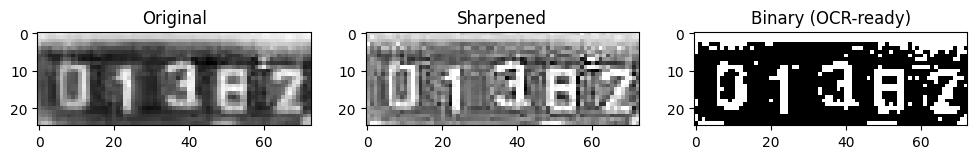

In [61]:

# 1. Configuration
image_path = '/content/crop_0.png'
sharpened_save_path = '/content/sharpened_crop_0.png'
binary_save_path = '/content/binary_crop_0.png'

# 2. Load and Preprocess
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image. Check path: {os.path.abspath(image_path)}")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Sharpening
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened = cv2.filter2D(gray, -1, kernel)

# Thresholding
_, binary = cv2.threshold(sharpened, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Save the results
cv2.imwrite(sharpened_save_path, sharpened)
cv2.imwrite(binary_save_path, binary)
print(f"Sharpened image saved to: {sharpened_save_path}")
print(f"Binary image saved to: {binary_save_path}")

# 4. Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.title("Original"), plt.imshow(gray, cmap='gray')
plt.subplot(1, 3, 2), plt.title("Sharpened"), plt.imshow(sharpened, cmap='gray')
plt.subplot(1, 3, 3), plt.title("Binary (OCR-ready)"), plt.imshow(binary, cmap='gray')
plt.show()

In [64]:
print(os.getcwd())

/content


# New section

In [62]:
result = ocr.predict(sharpened)

# 4. Display Results
print("\n--- Extracted Text ---")
for line in result[0]:
    text = line[1][0]
    confidence = line[1][1]
    print(f"Detected: '{text}' (Confidence: {confidence:.2f})")

IndexError: tuple index out of range